# Transcript search — experiment surface

This notebook does **not** reimplement the search engine. It imports it:

```python
from transcript_search import load_index
```

That single line is the whole point of this file. The engine lives in
`backend/transcript_search.py`, the FastAPI app imports the same module, and so
anything you prove here is *already true in the running app* — no copying, no
drift, no "which version was I tuning?"

The rule to keep: **the notebook asks questions, the module holds answers.**
If you change behaviour here, change it in the module and re-run this file. If
you find yourself pasting a function body into a cell, you are about to create
the second copy this layout exists to prevent.


In [14]:
import sys
from pathlib import Path

# Find backend/transcript_search.py whether this notebook sits beside the
# backend folder or one level above it. Walk up, and at each level also look
# one level down.
def find_backend(start: Path) -> Path:
    for base in [start, *start.parents]:
        if (base / "backend" / "transcript_search.py").exists():
            return base / "backend"
        for child in base.glob("*/backend/transcript_search.py"):
            return child.parent
    raise FileNotFoundError("transcript_search.py not found — is the backend folder nearby?")


BACKEND = find_backend(Path.cwd())
PROJECT = BACKEND.parent
if str(BACKEND) not in sys.path:
    sys.path.insert(0, str(BACKEND))

print("engine:", BACKEND / "transcript_search.py")


engine: D:\Ai engineering course\Projects\RAG_Lyrics_Generator\video-search\backend\transcript_search.py


In [15]:
import numpy as np
import matplotlib.pyplot as plt

from transcript_search import (
    TranscriptIndex,
    build_chunks,
    format_timecode,
    load_index,
    parse_pdf,
)

TRANSCRIPT = next(
    (p for base in (PROJECT.parent, PROJECT, Path.cwd()) for p in sorted(base.glob("*.pdf"))),
    None,
)
print("transcript:", TRANSCRIPT.name if TRANSCRIPT else "NOT FOUND — set TRANSCRIPT yourself")


transcript: Declan McKenna - Slipping Through My Fingers (Official Audio).pdf


## 1. What the parser actually produced

Before trusting any score, look at the units being scored. Most bad retrieval
is bad chunking wearing a maths costume.


In [16]:
index = load_index(TRANSCRIPT)

print(f"{len(index.chunks)} chunks · {format_timecode(index.duration)} · speakers={index.speakers}")
print()
for c in index.chunks:
    print(f"[{format_timecode(c.start_time)} → {format_timecode(c.end_time)}]  {len(c.text):>3} chars  {c.text[:64]}…")


6 chunks · 00:04:00 · speakers=['Speaker 1']

[00:00:02 → 00:00:34]  272 chars  School bag in hand, she leaves home in the early morning, waving…
[00:00:49 → 00:01:01]  142 chars  I'm glad whenever I can share Her laughter, that funny little gi…
[00:01:10 → 00:01:36]  295 chars  The feeling in it, slipping through my fingers all the time. Do …
[00:01:53 → 00:02:07]  249 chars  Then when she's gone, there's that old melancholy feeling and a …
[00:02:34 → 00:03:00]  273 chars  Slipping through my fingers all the time, I try to capture every…
[00:03:09 → 00:04:00]  221 chars  Sometimes I wish that I could freeze the picture and save it fro…


## 2. Search it

`index.search()` is the exact function `POST /api/search` calls. The `score`
here is the same number the API sends and the UI ignores.


In [17]:
QUERIES = [
    "slipping through my fingers",
    "school bag in the early morning",
    "wonderful adventures we planned",
    "artificial intelligence",   # matches nothing — this is the important one
]

for q in QUERIES:
    hits = index.search(q, k=3)
    print(f"\n{q!r} → {len(hits)} hit(s)")
    for h in hits:
        print(f"   {h['timestamp']}  score={h['score']:.3f}  {h['text'][:60]}…")



'slipping through my fingers' → 3 hit(s)
   00:02:34  score=0.420  Slipping through my fingers all the time, I try to capture e…
   00:01:10  score=0.294  The feeling in it, slipping through my fingers all the time.…
   00:00:49  score=0.238  I'm glad whenever I can share Her laughter, that funny littl…

'school bag in the early morning' → 2 hit(s)
   00:03:09  score=0.363  Sometimes I wish that I could freeze the picture and save it…
   00:00:02  score=0.333  School bag in hand, she leaves home in the early morning, wa…

'wonderful adventures we planned' → 1 hit(s)
   00:01:53  score=0.352  Then when she's gone, there's that old melancholy feeling an…

'artificial intelligence' → 0 hit(s)


### Why the last query returns nothing

Cosine similarity always returns *something*. Without a floor, a query that
matches nothing still yields the top-k least-irrelevant chunks — at score 0.0.
A UI built on that would confidently show three fake timestamps.

`min_score` is what turns a bad search into an honest empty result, and it is
the reason the app can say **"No matching section found"** and mean it. Watch
the difference:


In [18]:
q = "artificial intelligence"
print("with the floor   :", index.search(q, k=3))
print("without the floor:", [(h['timestamp'], h['score']) for h in index.search(q, k=3, min_score=0.0)])


with the floor   : []
without the floor: [('00:03:09', 0.0), ('00:02:34', 0.0), ('00:01:53', 0.0)]


## 3. The knob that matters most: `chunk_size`

It is a genuine trade-off, not a tuning detail.

- **Too small** → a query's words split across two chunks, neither scores well,
  the right moment never surfaces.
- **Too large** → the chunk matches, but `start_time` points minutes before the
  words you asked for. The timestamp is technically correct and useless.

Judge it on *timestamp accuracy*, not on score.


In [19]:
segments = parse_pdf(TRANSCRIPT)
PROBE = "wonderful adventures we planned"

for size in (120, 200, 300, 500, 900):
    trial = TranscriptIndex(build_chunks(segments, chunk_size=size))
    hits = trial.search(PROBE, k=1)
    top = hits[0] if hits else None
    print(
        f"chunk_size={size:>4}  chunks={len(trial.chunks):>3}  "
        + (f"top={top['timestamp']}  score={top['score']:.3f}" if top else "no match")
    )


chunk_size= 120  chunks= 12  top=00:02:07  score=0.459
chunk_size= 200  chunks=  9  top=00:02:07  score=0.459
chunk_size= 300  chunks=  6  top=00:01:53  score=0.352
chunk_size= 500  chunks=  4  top=00:02:07  score=0.303
chunk_size= 900  chunks=  2  top=00:02:07  score=0.232


## 4. Lexical vs latent

`"tfidf"` is exact word overlap: excellent at *find the line that says X*,
useless at *where does he talk about parenthood* if the word is never spoken.

`"lsa"` projects the TF-IDF matrix onto latent dimensions with TruncatedSVD, so
words that co-occur across the transcript end up near each other. On a
six-chunk transcript the latent space is very thin — keep expectations low.
It is the honest next step, not a fix.

**Both backends return the identical shape**, which is why the frontend cannot
tell them apart. Swapping is a one-word change:


In [7]:
PARAPHRASE = "a parent watching a child grow up and leave"

for backend in ("tfidf", "lsa"):
    trial = load_index(TRANSCRIPT, backend=backend)
    hits = trial.search(PARAPHRASE, k=2)
    print(f"\n{backend}: {len(hits)} hit(s)")
    for h in hits:
        print(f"   {h['timestamp']}  score={h['score']:.3f}  {h['text'][:60]}…")



tfidf: 0 hit(s)

lsa: 0 hit(s)


**Both returned nothing, and that is the correct result.** Not one word of that
paraphrase appears in the lyric, so TF-IDF has nothing to match — and LSA,
trained on six chunks, has nowhere near enough co-occurrence data to learn that
"parent", "child" and "grow up" belong near "slipping through my fingers".

This is the ceiling of lexical retrieval, measured rather than asserted. Real
sentence embeddings are trained on billions of sentences and would land this
query; that is the upgrade path in section 7, and it is a one-file change.


## 5. Look inside the vectoriser

Retrieval stops being magic the moment you can read the weights. High IDF =
rare in this transcript = discriminating. These are the terms that actually
decide your rankings.


In [8]:
names = index.vectorizer.get_feature_names_out()
idf = index.vectorizer.idf_
order = np.argsort(idf)

print("most COMMON terms (low idf — these barely help):")
for i in order[:8]:
    print(f"   {idf[i]:.3f}  {names[i]}")

print("\nmost DISCRIMINATING terms (high idf):")
for i in order[-8:][::-1]:
    print(f"   {idf[i]:.3f}  {names[i]}")

print("\nsuggestions the API derives from this transcript:")
print("  ", index.suggested_queries(4))


most COMMON terms (low idf — these barely help):
   1.336  fingers
   1.336  feeling
   1.336  slipping
   1.336  slipping fingers
   1.336  time
   1.560  fingers time
   1.560  really
   1.847  early morning

most DISCRIMINATING terms (high idf):
   2.253  world
   2.253  wonderful adventures
   2.253  wonderful
   2.253  wish freeze
   2.253  wish
   2.253  watch surge
   2.253  tricks
   2.253  watch

suggestions the API derives from this transcript:
   ['through my fingers', 'early morning waving goodbye', 'hand she leaves', 'absent minded smile']


## 6. Evaluate, don't vibe

This is the cell that separates using retrieval from engineering it.

Write down the queries you care about and the timestamp each *should* return.
Then every change you make — chunk size, backend, stop words, the floor — is
measured instead of felt. Twenty rows is enough to stop guessing.

Add your own. `expected=None` means "this should legitimately return nothing".


In [9]:
# query -> the timecode you believe is correct (None = should find nothing)
GOLD = {
    "slipping through my fingers": "00:02:34",
    "school bag in the early morning": "00:00:02",
    "wonderful adventures": "00:01:53",
    "freeze the picture": "00:03:09",
    "breakfast table": "00:01:10",
    "artificial intelligence": None,
}


def evaluate(idx, gold=GOLD, k=3):
    """Hit@1 and Hit@k, plus correct rejections. Returns a per-query table."""
    rows, hit1, hitk, rejected = [], 0, 0, 0

    for query, expected in gold.items():
        hits = idx.search(query, k=k)
        found = [h["timestamp"] for h in hits]

        if expected is None:
            ok = len(found) == 0
            rejected += ok
            rows.append((query, "(nothing)", found[:1] or ["—"], ok))
            continue

        at1 = bool(found) and found[0] == expected
        atk = expected in found
        hit1 += at1
        hitk += atk
        rows.append((query, expected, found, at1))

    answerable = sum(1 for v in gold.values() if v is not None)
    unanswerable = len(gold) - answerable
    print(f"Hit@1 {hit1}/{answerable}   Hit@{k} {hitk}/{answerable}   correct rejections {rejected}/{unanswerable}")
    return rows


for query, expected, found, ok in evaluate(index):
    print(f"  {'✓' if ok else '✗'} {query:<34} want={expected:<11} got={found}")


Hit@1 4/5   Hit@3 5/5   correct rejections 1/1
  ✓ slipping through my fingers        want=00:02:34    got=['00:02:34', '00:01:10', '00:00:49']
  ✗ school bag in the early morning    want=00:00:02    got=['00:03:09', '00:00:02']
  ✓ wonderful adventures               want=00:01:53    got=['00:01:53']
  ✓ freeze the picture                 want=00:03:09    got=['00:03:09']
  ✓ breakfast table                    want=00:01:10    got=['00:01:10']
  ✓ artificial intelligence            want=(nothing)   got=['—']


### Now sweep with the metric instead of your eyes

Same gold set, every chunk size. This is the loop worth building for any
retrieval system you touch.


In [10]:
for size in (120, 200, 300, 500, 900):
    trial = TranscriptIndex(build_chunks(segments, chunk_size=size))
    print(f"chunk_size={size:>4}  ", end="")
    evaluate(trial)


chunk_size= 120  Hit@1 1/5   Hit@3 2/5   correct rejections 1/1
chunk_size= 200  Hit@1 0/5   Hit@3 2/5   correct rejections 1/1
chunk_size= 300  Hit@1 4/5   Hit@3 5/5   correct rejections 1/1
chunk_size= 500  Hit@1 2/5   Hit@3 3/5   correct rejections 1/1
chunk_size= 900  Hit@1 0/5   Hit@3 1/5   correct rejections 1/1


## 7. Where scores actually sit

Before picking a `min_score`, look at the distribution. A floor chosen from a
histogram is a decision; a floor chosen from one lucky query is superstition.


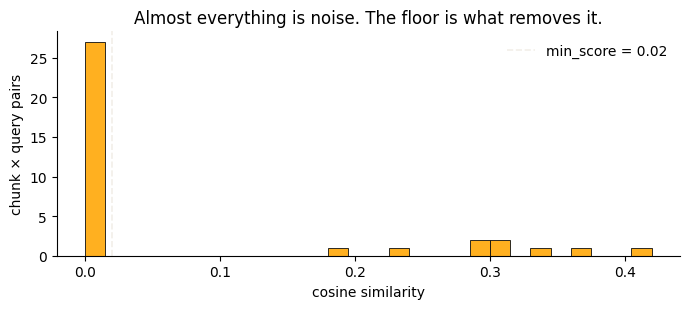

75% of all pairs fall below the floor


In [11]:
scores = []
for query in GOLD:
    qv = index.vectorizer.transform([query])
    scores.extend((index.matrix @ qv.T).toarray().flatten())

scores = np.array(scores)

fig, ax = plt.subplots(figsize=(7, 3.2))
ax.hist(scores, bins=28, color="#ffb020", edgecolor="#0b0c0d", linewidth=0.6)
ax.axvline(0.02, color="#f2efe9", linestyle="--", linewidth=1.2, label="min_score = 0.02")
ax.set_xlabel("cosine similarity")
ax.set_ylabel("chunk × query pairs")
ax.set_title("Almost everything is noise. The floor is what removes it.")
ax.legend(frameon=False)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

print(f"{(scores < 0.02).mean():.0%} of all pairs fall below the floor")


---

## Next

1. **Grow `GOLD` to twenty rows.** Include queries you expect to fail — a system
   that never says "no" is not accurate, it is agreeable.
2. **Swap in real embeddings.** `sentence-transformers`, encode each chunk once,
   cosine against the query vector. Add it as a third `backend` in
   `transcript_search.py` and re-run `evaluate()`. The API and the entire
   frontend stay untouched — that is what the module boundary bought you.
3. **Then go hybrid.** Lexical finds exact quotes, dense finds paraphrase. Fuse
   the two rankings (reciprocal rank fusion is ~10 lines) and measure again.

Change the module, re-run this notebook, watch the numbers move. Never paste a
function body into a cell.
